In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# print(data)  # 查看加载的数据

/home/nusbac/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Different FL algorithms 

In [3]:
breaks=10
q_ls =[]
for l in range(breaks+1):
    for j in range(breaks+1): # going through q, from 0 to 1 - 20 points
        q1 = l/10
        q2 = j/10
        q3 = 1-q1-q2
        if q3<0:
            break

        q_ls.append([q1,q2,q3])

q_ls = np.vstack(q_ls)


source_1_idx = []
source_2_idx = []
source_3_idx = []
source_4_idx = []
source_5_idx = []
for i in range(len(q_ls)):
    if len(np.where(q_ls[i]!=0)[0]) == 1:
        source_1_idx.append(i)
    if len(np.where(q_ls[i]!=0)[0]) == 2:
        source_2_idx.append(i)
    if len(np.where(q_ls[i]!=0)[0]) == 3:
        source_3_idx.append(i)
    if len(np.where(q_ls[i]!=0)[0]) == 4:
        source_4_idx.append(i)
    if len(np.where(q_ls[i]!=0)[0]) == 5:
        source_5_idx.append(i)

In [4]:
# dict_keys(['args', 'train_err_log_weight', 'train_err_log_uni', 'test_err_log', 'ot_log', 'accuracies'])

In [ ]:
mu_1=0.3
mu_2=0.3
sources='cif10_3sources'
data_size=6000
file_path_nova=f"results/{sources}/fednova_{data_size}_80_10.res"
file_path_fedavg=f"./{sources}/fedavg_{data_size}_80_10.res"
file_path_scaffold=f"results/{sources}/scaffold_{data_size}_80_10.res"
file_path_fedprox=f"results/{sources}/fedprox_{data_size}_80_10_{mu_1}.res"
file_path_fedprox_2=f"results/{sources}/fedprox_{data_size}_80_10_{mu_2}.res"

# dict_keys(['args', 'train_err_log_weight', 'train_err_log_uni', 'test_err_log', 'ot_log', 'accuracies'])


with open(file_path_nova, 'rb') as f:   
    data_fednova = pickle.load(f)


with open(file_path_scaffold, 'rb') as f:   
    data_scaffold = pickle.load(f)

with open(file_path_fedavg, 'rb') as f:   
    data_fedavg = pickle.load(f)


with open(file_path_fedprox, 'rb') as f:  
    data_fedprox = pickle.load(f)


with open(file_path_fedprox_2, 'rb') as f:  
    data_fedprox_2 = pickle.load(f)

ot_result_fednova= np.hstack(data_fednova['ot_log'])
ot_result_fedavg = np.hstack(data_fedavg['ot_log'])
ot_result_scaffold = np.hstack(data_scaffold['ot_log'])
ot_result_fedprox = np.hstack(data_fedprox['ot_log'])


for it_idx in [10*(i+1)-1 for i in range(8)]:
    acc_ls_fednova= []
    for i in range(len(data_fednova['accuracies'])):
        for item in data_fednova['accuracies'][i]:
            acc_ls_fednova.append(item[it_idx])


for it_idx in [10*(i+1)-1 for i in range(8)]:
    acc_ls_fedprox= []
    for i in range(len(data_fedprox['accuracies'])):
        for item in data_fedprox['accuracies'][i]:
            acc_ls_fedprox.append(item[it_idx])

for it_idx in [10*(i+1)-1 for i in range(8)]:
    acc_ls_fedprox_2= []
    for i in range(len(data_fedprox_2['accuracies'])):
        for item in data_fedprox_2['accuracies'][i]:
            acc_ls_fedprox_2.append(item[it_idx])


for it_idx in [10*(i+1)-1 for i in range(8)]:
    acc_ls_fedavg= []
    for i in range(len(data_fedavg['accuracies'])):
        for item in data_fedavg['accuracies'][i]:
            acc_ls_fedavg.append(item[it_idx])

for it_idx in [10*(i+1)-1 for i in range(8)]:
    acc_ls_scaffold= []
    for i in range(len(data_scaffold['accuracies'])):
        for item in data_scaffold['accuracies'][i]:
            acc_ls_scaffold.append(item[it_idx])


            
for it_idx in [10*(i+1)-1 for i in range(8)]:
    error_ls_fedprox= []
    for i in range(len(data_fedprox['train_err_log_weight'])):
        for item in data_fedprox['train_err_log_weight'][i]:
            error_ls_fedprox.append(item[it_idx])


for it_idx in [10*(i+1)-1 for i in range(8)]:
    error_ls_fedprox_2= []
    for i in range(len(data_fedprox_2['train_err_log_weight'])):
        for item in data_fedprox_2['train_err_log_weight'][i]:
            error_ls_fedprox_2.append(item[it_idx])



for it_idx in [10*(i+1)-1 for i in range(8)]:
    error_ls_scaffold= []
    for i in range(len(data_scaffold['train_err_log_weight'])):
        for item in data_scaffold['train_err_log_weight'][i]:
            error_ls_scaffold.append(item[it_idx])

for it_idx in [10*(i+1)-1 for i in range(8)]:
    error_ls_fednova = []
    for i in range(len(data_fednova['train_err_log_weight'])):
        for item in data_fednova['train_err_log_weight'][i]:
            error_ls_fednova.append(item[it_idx])

for it_idx in [10*(i+1)-1 for i in range(8)]:
    error_ls_fedavg= []
    for i in range(len(data_fedavg['train_err_log_weight'])):
        for item in data_fedavg['train_err_log_weight'][i]:
            error_ls_fedavg.append(item[it_idx])




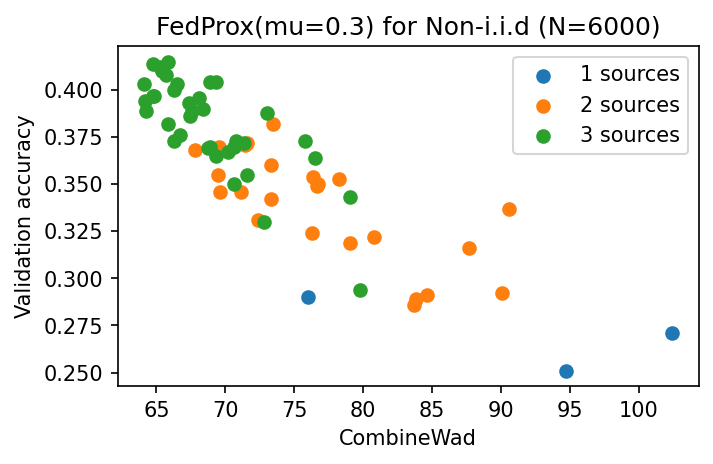

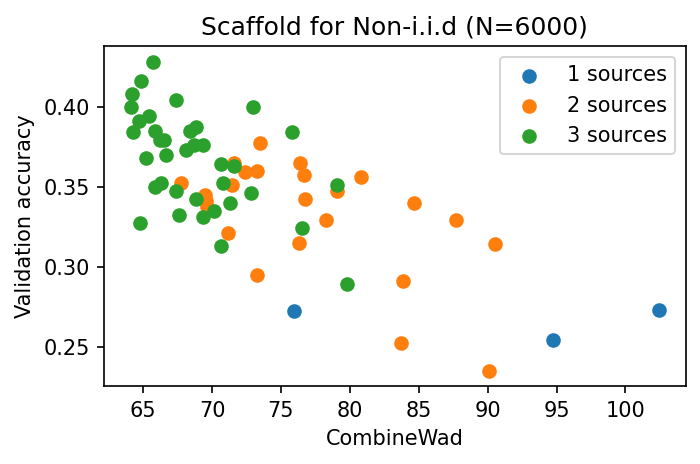

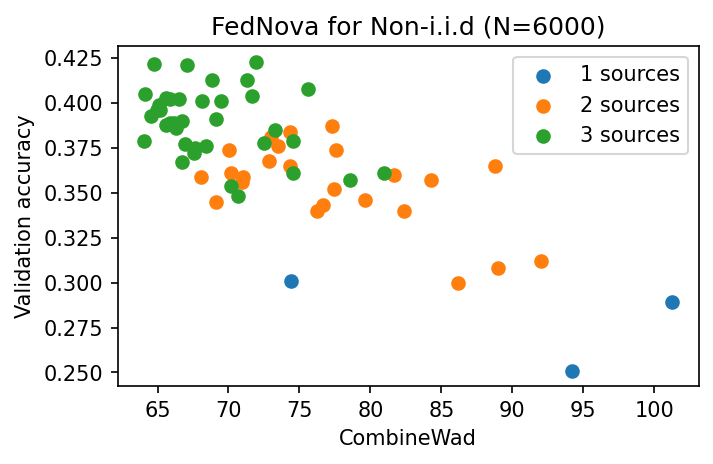

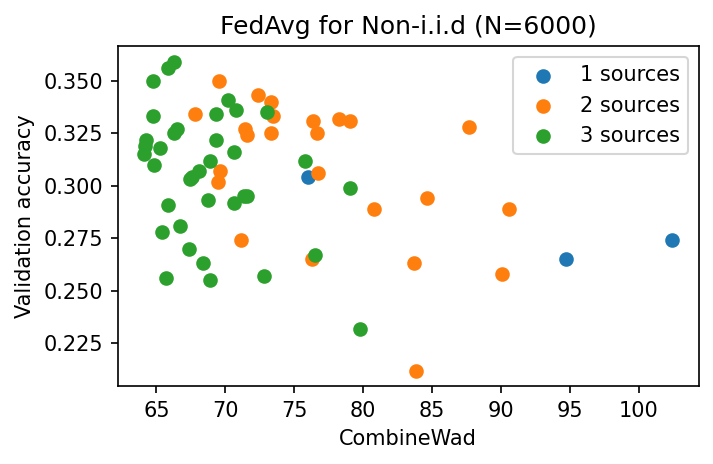

In [43]:
fg = plt.figure(figsize=(5,3),dpi=150)
plt.scatter(ot_result_fedavg[source_1_idx],np.array(acc_ls_fedprox)[source_1_idx],label='1 sources')
plt.scatter(ot_result_fedavg[source_2_idx],np.array(acc_ls_fedprox)[source_2_idx],label='2 sources')
plt.scatter(ot_result_fedavg[source_3_idx],np.array(acc_ls_fedprox)[source_3_idx],label='3 sources')
plt.xlabel('CombineWad')
plt.ylabel('Validation accuracy')
plt.title(f'FedProx(mu={mu_1}) for Non-i.i.d (N={data_size})')
plt.legend()

plt.savefig(f'/mnt/sda/projektor/result_rebuttal/fedprox_noniid_dots_{data_size}.png',bbox_inches='tight')


# fg = plt.figure(figsize=(5,3),dpi=150)
# plt.scatter(ot_result_fedavg[source_1_idx],np.array(acc_ls_fedprox_2)[source_1_idx],label='1 sources')
# plt.scatter(ot_result_fedavg[source_2_idx],np.array(acc_ls_fedprox_2)[source_2_idx],label='2 sources')
# plt.scatter(ot_result_fedavg[source_3_idx],np.array(acc_ls_fedprox_2)[source_3_idx],label='3 sources')
# plt.xlabel('CombineWad')
# plt.ylabel('Validation accuracy')
# plt.title(f'FedProx(mu={mu_2}) for Non-i.i.d (N={data_size})')
# plt.legend()

# plt.savefig(f'/mnt/sda/projektor/result_rebuttal/fedprox_noniid_dots_{data_size}_mu_0.3.png',bbox_inches='tight')


fg = plt.figure(figsize=(5,3),dpi=150)
plt.scatter(ot_result_fedavg[source_1_idx],np.array(acc_ls_scaffold)[source_1_idx],label='1 sources')
plt.scatter(ot_result_fedavg[source_2_idx],np.array(acc_ls_scaffold)[source_2_idx],label='2 sources')
plt.scatter(ot_result_fedavg[source_3_idx],np.array(acc_ls_scaffold)[source_3_idx],label='3 sources')
plt.xlabel('CombineWad')
plt.ylabel('Validation accuracy')
plt.title(f'Scaffold for Non-i.i.d (N={data_size})')
plt.legend()

plt.savefig(f'/mnt/sda/projektor/result_rebuttal/scaffold_noniid_dots_{data_size}.png',bbox_inches='tight')

fg = plt.figure(figsize=(5,3),dpi=150)
plt.scatter(ot_result_fednova[source_1_idx],np.array(acc_ls_fednova)[source_1_idx],label='1 sources')
plt.scatter(ot_result_fednova[source_2_idx],np.array(acc_ls_fednova)[source_2_idx],label='2 sources')
plt.scatter(ot_result_fednova[source_3_idx],np.array(acc_ls_fednova)[source_3_idx],label='3 sources')
plt.xlabel('CombineWad')
plt.ylabel('Validation accuracy')
plt.title(f'FedNova for Non-i.i.d (N={data_size})')
plt.legend()
plt.savefig(f'/mnt/sda/projektor/result_rebuttal/fednova_noniid_dots_{data_size}.png',bbox_inches='tight')


fg = plt.figure(figsize=(5,3),dpi=150)
plt.scatter(ot_result_fedavg[source_1_idx],np.array(acc_ls_fedavg)[source_1_idx],label='1 sources')
plt.scatter(ot_result_fedavg[source_2_idx],np.array(acc_ls_fedavg)[source_2_idx],label='2 sources')
plt.scatter(ot_result_fedavg[source_3_idx],np.array(acc_ls_fedavg)[source_3_idx],label='3 sources')
plt.xlabel('CombineWad')
plt.ylabel('Validation accuracy')
plt.title(f'FedAvg for Non-i.i.d (N={data_size})')
plt.legend()
plt.savefig(f'/mnt/sda/projektor/result_rebuttal/fedavg_noniid_dots_{data_size}.png',bbox_inches='tight')

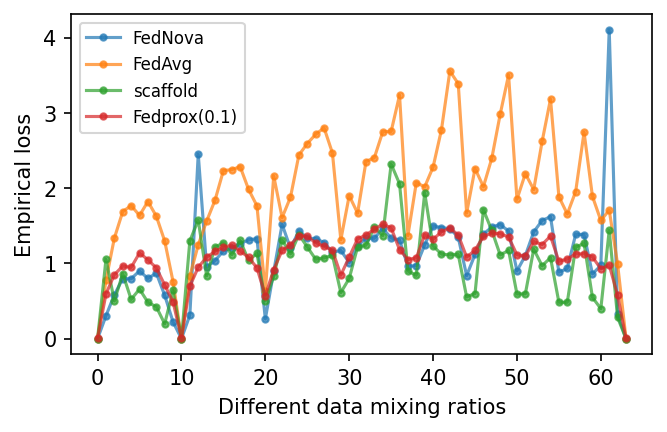

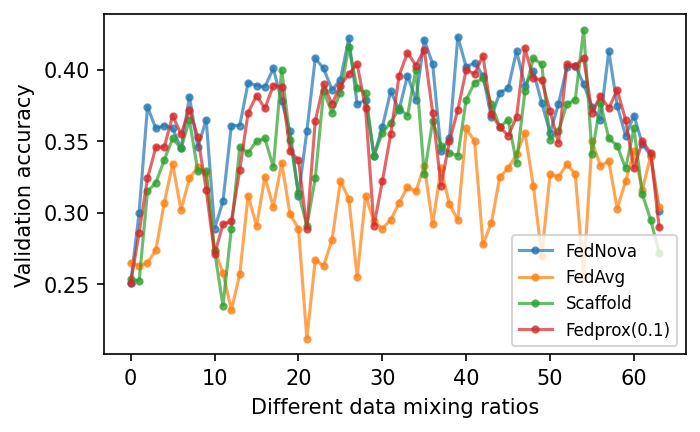

In [44]:
fg1 = plt.figure(figsize=(5,3),dpi=150)
plt.plot(error_ls_fednova,label='FedNova',marker='.',alpha=0.7)
plt.plot(error_ls_fedavg,label='FedAvg',marker='.',alpha=0.7)
plt.plot(error_ls_scaffold,label='scaffold',marker='.',alpha=0.7)
plt.plot(error_ls_fedprox,label='Fedprox(0.1)',marker='.',alpha=0.7)
# plt.plot(error_ls_fedprox_2,label='Fedprox(0.3)',marker='.',alpha=0.7)
plt.legend(fontsize=8)
plt.xlabel('Different data mixing ratios')
plt.ylabel('Empirical loss')
plt.savefig(f'/mnt/sda/projektor/result_rebuttal/train_loss_comparison_{data_size}.png',bbox_inches='tight')

fg2 = plt.figure(figsize=(5,3),dpi=150)
plt.plot(acc_ls_fednova,label='FedNova',marker='.',alpha=0.7)
plt.plot(acc_ls_fedavg,label='FedAvg',marker='.',alpha=0.7)
plt.plot(acc_ls_scaffold,label='Scaffold',marker='.',alpha=0.7)
plt.plot(acc_ls_fedprox,label='Fedprox(0.1)',marker='.',alpha=0.7)
# plt.plot(acc_ls_fedprox_2,label='Fedprox(0.3)',marker='.',alpha=0.7)
plt.xlabel('Different data mixing ratios')
plt.ylabel('Validation accuracy')
plt.legend(fontsize=8,loc='lower right')
plt.savefig(f'/mnt/sda/projektor/result_rebuttal/val_accuracy_comparison_{data_size}.png',bbox_inches='tight')